In [13]:
import pandas as pd
from sklearn.linear_model import LinearRegression, SGDRegressor, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    accuracy_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.svm import SVC

LOADING THE DATA

In [2]:
# ...existing code...
import os, glob, pandas as pd

print("cwd:", os.getcwd())
print("files in cwd (sample):", sorted(os.listdir())[:30])

def find_file(fname):
    if os.path.isfile(fname):
        return os.path.abspath(fname)
    matches = glob.glob(f"**/{fname}", recursive=True)
    return matches[0] if matches else None

train_path = find_file("train.csv")
test_path  = find_file("test.csv")

if not train_path or not test_path:
    raise FileNotFoundError(
        f"Missing files. train.csv -> {train_path}, test.csv -> {test_path}.\n"
        "Move CSVs to the notebook working directory or provide absolute paths."
    )

print("Using:", train_path, test_path)
train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)
print("Loaded shapes:", train_df.shape, test_df.shape)
# ...existing code...

cwd: c:\Users\MIRZA REHAAN BAIG\Desktop\SUMAIYYA MIRZA\code\code\SentinelNet_Oct_Batch\SentinelNet_Oct_Batch
files in cwd (sample): ['.git', 'Dataset1.py', 'Dataset_info_checkpoints.ipynb', 'EDA_Checkpoints.ipynb', 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'KDD (1).ipynb', 'LICENSE', 'LogisticRegression.ipynb', 'ML_models.ipynb', 'Model_Evaluation.ipynb', 'README.md', 'SentinelNet_Oct_Batch', 'Untitled-1.ipynb', 'charts 111.py', 'dataset1_info.py', 'dataset2_info.py', 'feature_names.txt', 'kdd_encoders.pkl', 'main.py', 'model_training.ipynb', 'test.csv', 'train.csv']
Using: c:\Users\MIRZA REHAAN BAIG\Desktop\SUMAIYYA MIRZA\code\code\SentinelNet_Oct_Batch\SentinelNet_Oct_Batch\train.csv c:\Users\MIRZA REHAAN BAIG\Desktop\SUMAIYYA MIRZA\code\code\SentinelNet_Oct_Batch\SentinelNet_Oct_Batch\test.csv
Loaded shapes: (125973, 42) (22544, 42)


In [5]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [6]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [7]:
TARGET_COLUMN = 'attack_binary' 
FEATURE_COLUMNS = [col for col in train_df.columns if col != TARGET_COLUMN]

In [19]:
# ...existing code...
import os, glob, pandas as pd

def find(f):
    if os.path.isfile(f): return f
    matches = glob.glob(f"**/{f}", recursive=True)
    return matches[0] if matches else None

train_p, test_p = find("train.csv"), find("test.csv")
if not train_p or not test_p:
    raise FileNotFoundError(f"train.csv={train_p}, test.csv={test_p}")

train_df = pd.read_csv(train_p)
test_df  = pd.read_csv(test_p)

# ensure target exists
TARGET_COLUMN = 'attack_binary'
for df in (train_df, test_df):
    if TARGET_COLUMN not in df.columns and 'labels' in df.columns:
        df[TARGET_COLUMN] = df['labels'].apply(lambda x: 0 if x == 'normal' else 1)

if TARGET_COLUMN not in train_df.columns or TARGET_COLUMN not in test_df.columns:
    raise KeyError(f"'{TARGET_COLUMN}' missing in train or test")

# consistent feature selection (only columns present in both)
features = [c for c in train_df.columns if c != TARGET_COLUMN and c in test_df.columns]
if not features:
    raise ValueError("No shared feature columns found between train and test")

X_train, y_train = train_df[features].copy(), train_df[TARGET_COLUMN].copy()
X_test,  y_test  = test_df[features].copy(),  test_df[TARGET_COLUMN].copy()

print("X_train:", X_train.shape, "X_test:", X_test.shape)
# ...existing code...

X_train: (125973, 42) X_test: (22544, 42)


In [24]:
X_train = train_df[FEATURE_COLUMNS]
y_train = train_df[TARGET_COLUMN]
X_test = test_df[FEATURE_COLUMNS]
y_test = test_df[TARGET_COLUMN]

In [ ]:
# ...existing code...
import numpy as np
from sklearn.preprocessing import StandardScaler

if 'X_train' not in globals() or 'X_test' not in globals():
    raise NameError("X_train/X_test not defined")

# keep numeric columns, align columns between train/test
X_train = X_train.select_dtypes(include=[np.number]).copy()
X_test  = X_test.select_dtypes(include=[np.number]).copy()
X_train, X_test = X_train.align(X_test, join='outer', axis=1, fill_value=0)


In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
print(f"prepared and data loaded for {len(FEATURE_COLUMNS)} features and target '{TARGET_COLUMN}'.\n")

prepared and data loaded for 42 features and target 'attack_binary'.



In [36]:
test_df.shape

(22544, 43)

In [37]:
train_df.shape

(125973, 43)

In [38]:
print(train_df.describe())

           duration     src_bytes     dst_bytes           land  \
count  125973.00000  1.259730e+05  1.259730e+05  125973.000000   
mean      287.14465  4.556674e+04  1.977911e+04       0.000198   
std      2604.51531  5.870331e+06  4.021269e+06       0.014086   
min         0.00000  0.000000e+00  0.000000e+00       0.000000   
25%         0.00000  0.000000e+00  0.000000e+00       0.000000   
50%         0.00000  4.400000e+01  0.000000e+00       0.000000   
75%         0.00000  2.760000e+02  5.160000e+02       0.000000   
max     42908.00000  1.379964e+09  1.309937e+09       1.000000   

       wrong_fragment         urgent            hot  num_failed_logins  \
count   125973.000000  125973.000000  125973.000000      125973.000000   
mean         0.022687       0.000111       0.204409           0.001222   
std          0.253530       0.014366       2.149968           0.045239   
min          0.000000       0.000000       0.000000           0.000000   
25%          0.000000       0.00000

In [39]:
print(f'Training data percentage:{(train_df.shape[0]/(train_df.shape[0]+test_df.shape[0]))*100}')
print(f'Testing data percentage:{(test_df.shape[0]/(train_df.shape[0]+test_df.shape[0]))*100}')

Training data percentage:84.82059292875563
Testing data percentage:15.17940707124437


CORRELATION HEATMAP

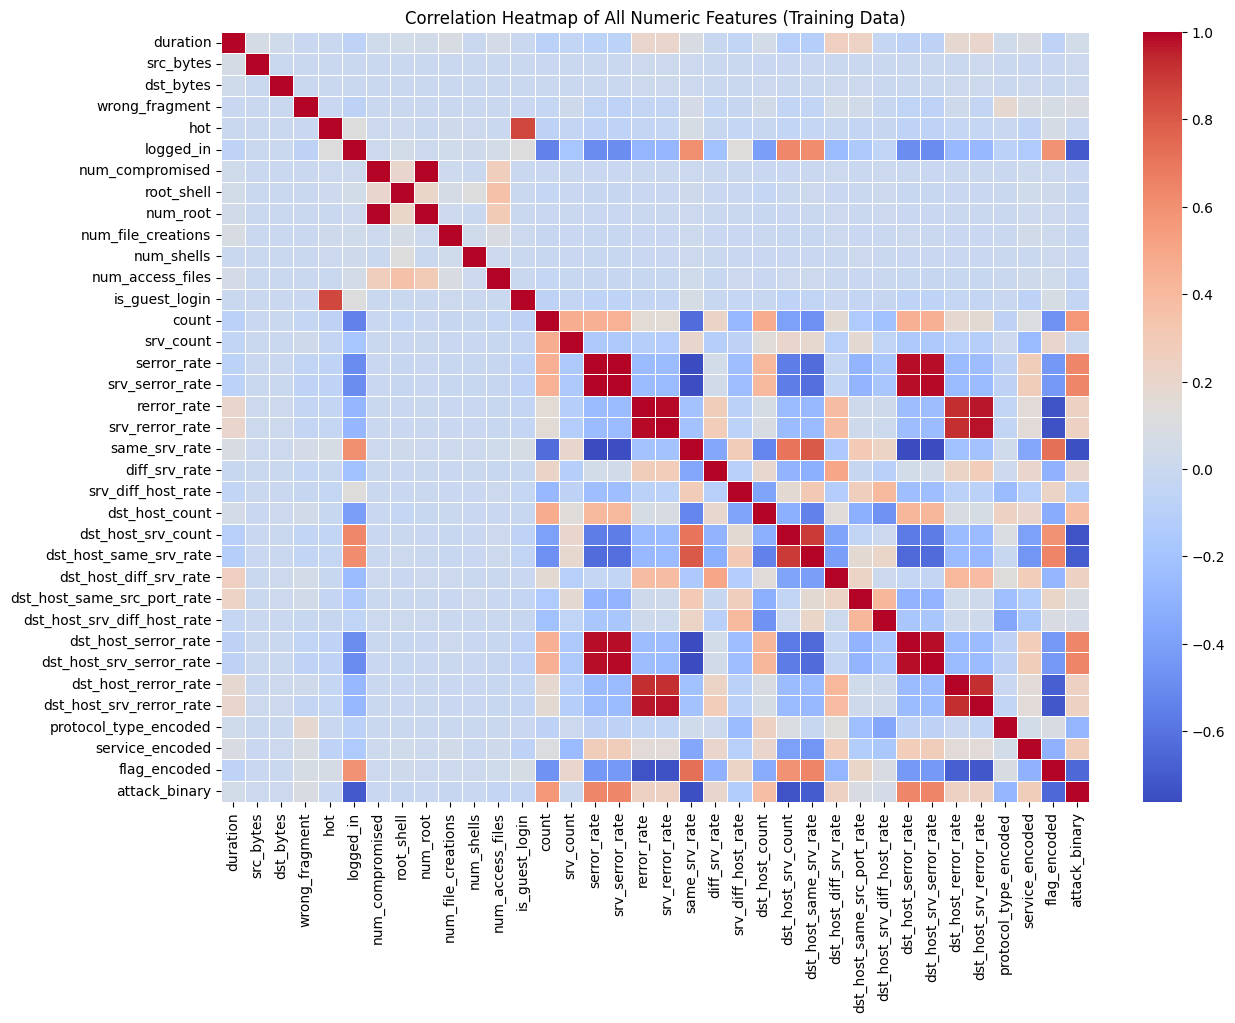

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your datasets
df_train_data = pd.read_csv("kdd_train_final.csv")
df_test_data = pd.read_csv("kdd_test_final.csv")

# Select only numeric columns
numeric_df = df_train_data.select_dtypes(include='number')

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Correlation Heatmap of All Numeric Features (Training Data)')
plt.show()


Create the dictionary to save all the binary classification models

In [78]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# MODELS
from sklearn.linear_model import LinearRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# --------------------------------------------------------
# LOAD BOTH FILES AND COMBINE
# --------------------------------------------------------
df_train = pd.read_csv("kdd_train_final.csv")
df_test  = pd.read_csv("kdd_test_final.csv")

df = pd.concat([df_train, df_test], ignore_index=True)

# --------------------------------------------------------
# 1. DEFINE FEATURES AND LABEL
# --------------------------------------------------------
y = df['attack_binary']          # TARGET COLUMN
X = df.drop(columns=['attack_binary'])

# --------------------------------------------------------
# 2. TRAIN-TEST SPLIT
# --------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --------------------------------------------------------
# 3. SCALING
# --------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# --------------------------------------------------------
# 4. MODELS
# --------------------------------------------------------
models = {
    "Linear Regression (OLS)": LinearRegression(),
    "Gradient Descent (SGD)": SGDClassifier(loss='log_loss'),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=120),
    "SVM RBF": SVC(),
    "KNN": KNeighborsClassifier()
}

results = {}

# --------------------------------------------------------
# 5. TRAIN / TEST LOOP
# --------------------------------------------------------
for name, model in models.items():

    print(f"\n{'='*20} {name} {'='*20}")

    if name == "Linear Regression (OLS)":
        model.fit(X_train_scaled, y_train)
        y_train_pred = (model.predict(X_train_scaled) >= 0.5).astype(int)
        y_pred = (model.predict(X_test_scaled) >= 0.5).astype(int)

    else:
        model.fit(X_train_scaled, y_train)
        y_train_pred = model.predict(X_train_scaled)
        y_pred = model.predict(X_test_scaled)

    # METRICS
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc  = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    rep = classification_report(y_test, y_pred, output_dict=True)

    # STORE
    results[name] = {
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "confusion_matrix": cm,
        "report": rep
    }

    # PRINT
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy : {test_acc:.4f}")
    print(f"Recall Attack : {rep['1']['recall']:.4f}")
    print("Confusion Matrix:\n", cm)
    print("-"*50)



==================== Linear Regression (OLS) ====================
Train Accuracy: 0.9429
Test Accuracy : 0.9425
Recall Attack : 0.9300
Confusion Matrix:
 [[12438   586]
 [  912 12123]]
--------------------------------------------------

==================== Gradient Descent (SGD) ====================
Train Accuracy: 0.9426
Test Accuracy : 0.9413
Recall Attack : 0.9333
Confusion Matrix:
 [[12364   660]
 [  870 12165]]
--------------------------------------------------

==================== Decision Tree ====================
Train Accuracy: 0.9999
Test Accuracy : 0.9969
Recall Attack : 0.9959
Confusion Matrix:
 [[12995    29]
 [   53 12982]]
--------------------------------------------------

==================== Random Forest ====================
Train Accuracy: 0.9999
Test Accuracy : 0.9976
Recall Attack : 0.9960
Confusion Matrix:
 [[13013    11]
 [   52 12983]]
--------------------------------------------------

==================== SVM RBF ====================
Train Accuracy: 0.9884

In [79]:
def plot_cm(name):
    cm = results[name]["confusion_matrix"]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["Normal (0)", "Attack (1)"])
    disp.plot(cmap="Blues")
    plt.title(f"{name} – Confusion Matrix")
    plt.show()

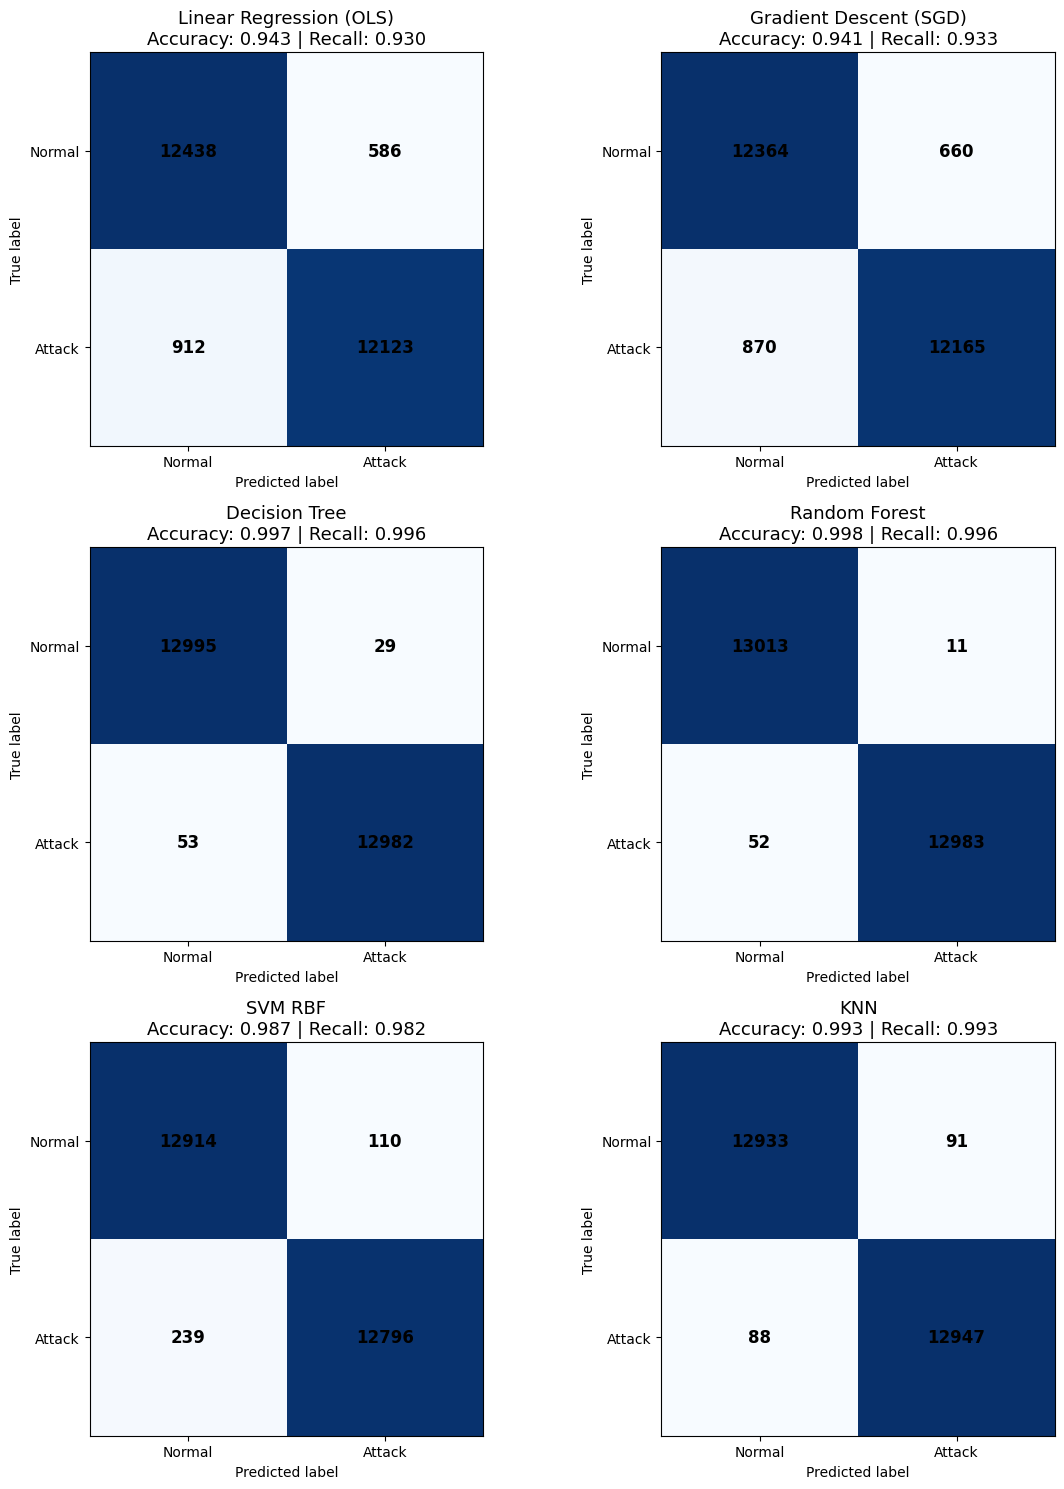

In [86]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

n = len(results)
cols = 2
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
axes = axes.flatten() if n > 1 else [axes]

for idx, (name, res) in enumerate(results.items()):
    cm = res["confusion_matrix"]
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Attack'])

    disp.plot(ax=axes[idx], cmap="Blues", colorbar=False)

    # ---- Make numbers clear and fully visible ----
    for text in axes[idx].texts:
        text.set_color("black")       # number color
        text.set_fontsize(12)         # bigger size
        text.set_weight("bold")       # bold text

    # ---- Add metrics ----
    acc = res["test_accuracy"]
    recall = res["report"]['1']['recall']

    axes[idx].set_title(
        f"{name}\nAccuracy: {acc:.3f} | Recall: {recall:.3f}",
        fontsize=13
    )

# Hide unused axes
for idx in range(n, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


In [84]:
results

{'Linear Regression (OLS)': {'train_accuracy': 0.9428971630865465,
  'test_accuracy': 0.9425150619747497,
  'confusion_matrix': array([[12438,   586],
         [  912, 12123]]),
  'report': {'0': {'precision': 0.9316853932584269,
    'recall': 0.9550061425061425,
    'f1-score': 0.9432016379767953,
    'support': 13024.0},
   '1': {'precision': 0.9538909434259186,
    'recall': 0.9300345224395857,
    'f1-score': 0.9418116842759477,
    'support': 13035.0},
   'accuracy': 0.9425150619747497,
   'macro avg': {'precision': 0.9427881683421728,
    'recall': 0.9425203324728642,
    'f1-score': 0.9425066611263715,
    'support': 26059.0},
   'weighted avg': {'precision': 0.9427928550349055,
    'recall': 0.9425150619747497,
    'f1-score': 0.9425063677634123,
    'support': 26059.0}}},
 'Gradient Descent (SGD)': {'train_accuracy': 0.9426093463682327,
  'test_accuracy': 0.9412870793200047,
  'confusion_matrix': array([[12364,   660],
         [  870, 12165]]),
  'report': {'0': {'precision':

In [89]:
import pandas as pd

data = []
for name, r in results.items():
    rep = r["report"]        # <-- fixed key
    cm = r["confusion_matrix"]
    
    data.append({
        "Model": name,
        "Train_Accuracy": r["train_accuracy"],
        "Test_Accuracy": r["test_accuracy"],
        "Gap": r["train_accuracy"] - r["test_accuracy"],
        "Precision": rep["1"]["precision"],
        "Recall": rep["1"]["recall"],
        "F1_Score": rep["1"]["f1-score"],
        "TN": cm[0,0],
        "FP": cm[0,1],
        "FN": cm[1,0],
        "TP": cm[1,1]
    })

df = pd.DataFrame(data)
df.to_excel("summary.xlsx", index=False)
print("✓ Saved to summary.xlsx - Open with Excel")


✓ Saved to summary.xlsx - Open with Excel


In [91]:
data = []
for name, r in results.items():
    rep = r["report"]
    cm = r["confusion_matrix"]
    
    data.append({
        "Model": name,
        "Train_Accuracy": r["train_accuracy"],
        "Test_Accuracy": r["test_accuracy"],
        "Gap": r["train_accuracy"] - r["test_accuracy"],
        "Precision": rep["1"]["precision"],
        "Recall": rep["1"]["recall"],
        "F1_Score": rep["1"]["f1-score"],
        "TN": cm[0,0],
        "FP": cm[0,1],
        "FN": cm[1,0],
        "TP": cm[1,1]
    })

df = pd.DataFrame(data)

# Save as formatted text
with open("summary.txt", "w", encoding="utf-8") as f:
    f.write(df.to_string(index=False))

print("✓ Saved to summary.txt (UTF-8 encoded)")

✓ Saved to summary.txt (UTF-8 encoded)
